## ML analysis with sif, ppt, tmean, tdmean, original NEE

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path(".").resolve().parent))

In [2]:
import pandas as pd
import numpy as np
import sklearn
import shap
from constants import *

c:\Users\qifanw\Documents\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
nee_msa_mean = pd.read_csv(NEE_MSA_MONTHLY_MEAN_XBASE)

# Extract columns for nee
orig_cols = ['NAMELSAD'] + [col.replace("nee_mean_", "") for col in nee_msa_mean.columns if "nee_mean_" in col]

orig_nee_stats = nee_msa_mean[['NAMELSAD'] + [f"nee_mean_{col}" for col in orig_cols[1:]]].rename(columns=lambda x: x.replace("nee_mean_", "") if "nee_mean_" in x else x)
orig_nee_stats.rename({'NAMELSAD': 'msa'}, axis=1, inplace=True)



In [4]:
ppt_stats = pd.read_csv(PPT_MEAN_FILE)
tmean_stats = pd.read_csv(TMEAN_MEAN_FILE)
tdmean_stats = pd.read_csv(TDMEAN_MEAN_FILE)
sif_stats = pd.read_csv(SIF_MEAN_FILE)
cs_trend = pd.read_csv(CS_XBASE_TREND)

ppt_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
tmean_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
tdmean_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
sif_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)


ppt_stats = ppt_stats.rename(columns={col: f"{col}_ppt" for col in ppt_stats.columns if col != "msa"})
tmean_stats = tmean_stats.rename(columns={col: f"{col}_tmean" for col in tmean_stats.columns if col != "msa"})
tdmean_stats = tdmean_stats.rename(columns={col: f"{col}_tdmean" for col in tdmean_stats.columns if col != "msa"})
sif_stats = sif_stats.rename(columns={col: f"{col}_sif" for col in sif_stats.columns if col != "msa"})
orig_nee_stats = orig_nee_stats.rename(columns={col: f"{col}_nee" for col in orig_nee_stats.columns if col != "msa"})

# Merge datasets on 'msa' column
df = ppt_stats.merge(tmean_stats, on="msa") \
              .merge(tdmean_stats, on="msa") \
              .merge(sif_stats, on="msa") \
              .merge(orig_nee_stats, on="msa")
              

df_long = df.melt(id_vars=['msa'], var_name='time', value_name='value')

# Separate target (NEE) and predictors
df_long['variable'] = df_long['time'].str.split('_').str[-1] 
df_long['time'] = df_long['time'].str.split('_').str[0]  

# Pivot table
df_pivot = df_long.pivot_table(index=['msa', 'time'], columns='variable', values='value').reset_index()

df_pivot = df_pivot.merge(cs_trend[['NAMELSAD','trend']].rename(columns={'NAMELSAD':'msa'}), on="msa")

In [ ]:
# # Scale x variables
# from sklearn.preprocessing import StandardScaler

# # Initialize the scaler
# scaler = StandardScaler()

# # Scale the specified columns
# df_pivot[['ppt', 'sif', 'tdmean', 'tmean']] = scaler.fit_transform(df_pivot[['ppt', 'sif', 'tdmean', 'tmean']])

### Fit ML Model for different regions

In [5]:
# Import libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
import random

from scipy.integrate import odeint
from IPython.display import Image

# Sklearn specific functions used in this lecture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, r2_score


# Suppress warnings
warnings.filterwarnings('ignore')

# Set number of decimals for np print options
np.set_printoptions(precision=3)


#### Prepare dataset for each region

In [6]:
# import re
# def get_region(msa_name):
#     pattern = r",\s([^,]+)\sMetro Area$"
#     state = re.search(pattern, msa_name).group(1)
#     for region, states in regions.items():
#         if state in states:
#             return region

# df_pivot["region"] = df_pivot["msa"].apply(get_region)
regions = CLIMATE_ZONE
msa_name_region = pd.read_csv(MSA_NAME_REGION_TABLE).rename(columns={"NAMELSAD":"msa"})
df_pivot = df_pivot.merge(msa_name_region, on='msa',how="left")

In [33]:
df_pivot.columns

Index(['msa', 'time', 'nee', 'ppt', 'sif', 'tdmean', 'tmean', 'trend',
       'region'],
      dtype='object')

In [7]:
df_pivot[['msa', 'time', 'nee', 'ppt', 'sif', 'tdmean', 'tmean','region','trend']].to_csv('../../data/intermedia/ml_raw_data_xbase.csv')

In [18]:
df_pivot[(df_pivot['region']=='southwest') & (df_pivot['sif']>3500)]

,msa,time,nee,ppt,sif,tdmean,tmean,trend,region
75348,"Salt Lake City-Murray, UT Metro Area",200101,0.251351,12.155050,3682.575615,-8.613801,-3.238694,no trend,southwest
75349,"Salt Lake City-Murray, UT Metro Area",200102,0.262706,18.596320,3682.097304,-5.825654,0.309334,no trend,southwest
75350,"Salt Lake City-Murray, UT Metro Area",200103,0.254615,35.561369,3758.984760,-2.258072,6.299275,no trend,southwest
75351,"Salt Lake City-Murray, UT Metro Area",200104,0.088985,41.237431,3916.660023,-2.187256,8.911645,no trend,southwest
75352,"Salt Lake City-Murray, UT Metro Area",200105,-0.002578,3.104680,4071.618992,-1.866014,16.514186,no trend,southwest
...,...,...,...,...,...,...,...,...,...
75559,"Salt Lake City-Murray, UT Metro Area",201808,0.252878,9.785787,3899.559203,1.713781,24.133837,no trend,southwest
75560,"Salt Lake City-Murray, UT Metro Area",201809,0.130625,0.128459,3797.082063,-3.963947,19.696804,no trend,southwest
75561,"Salt Lake City-Murray, UT Metro Area",201810,0.394040,47.500862,3816.670574,0.010430,9.736528,no trend,southwest
75562,"Salt Lake City-Murray, UT Metro Area",201811,0.284958,23.352690,3740.635404,-7.800719,1.365232,no trend,southwest


In [ ]:
# import geopandas as gpd
# # Load the dataset
# msa_file = '../../gis/msa/msaUS_mland_aea1_M1.shp'
# msa_gdf_crsaea = gpd.read_file(msa_file)
# msa_gdf_crsaea.to_file("../../gis/msa/region/msa_region.shp", driver="ESRI Shapefile")

In [8]:
from collections import defaultdict
x_vars = ['ppt', 'tmean', 'tdmean', 'sif']
y_var = 'nee'
 
# selected_region = 'northeast'
dataset_region = defaultdict(dict)
for region in regions.keys():
    for trend in ['increasing', 'decreasing', 'no trend']:
        df_filtered = df_pivot[(df_pivot["region"] == region) & (df_pivot["trend"] == trend)]
        X_region = df_filtered[x_vars]
        y_region = df_filtered[y_var]

        # Split the dataset into training and testing sets
        try:
            X_train, X_test, y_train, y_test = train_test_split(X_region, y_region, test_size=0.2, random_state=42)
            dataset_region[region][trend] = (X_train, X_test, y_train, y_test)
        except ValueError as e:
            print(f"Error splitting data for region {region} with trend {trend}: {e}")
            dataset_region[region][trend] = (None, None, None, None)



Error splitting data for region upper_midwest with trend increasing: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.
Error splitting data for region upper_midwest with trend decreasing: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.
Error splitting data for region ohio_valley with trend decreasing: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.


#### Random Forest Regressor for all regions

In [9]:
folder_name = '../../figures/rf_sif_region_trend_XBASE/'

In [10]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
results_list = []
for region in dataset_region.keys():
    for trend in dataset_region[region].keys():
        if dataset_region[region][trend][0] is None:
            print(f"No data available for region {region} with trend {trend}.")
            continue
        print(f"--- Region: {region}, Trend: {trend}, Training sample size: {len(dataset_region[region][trend][0])} ---")
        X_train, X_test, y_train, y_test = dataset_region[region][trend]
        
        # Initialize the Regressor
        regressor = RandomForestRegressor(random_state=42)

        # Train the regressor
        regressor.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = regressor.predict(X_test)


        # results = pd.DataFrame(np.column_stack((y_pred,y_test)), columns= ['y_pred', 'y_test'])

        # # Create scatter plot
        # plt.figure(figsize=(12, 12))
        # sns.scatterplot(data=results, x="y_test", y="y_pred", alpha=0.8, edgecolor="black")

        # plt.xlabel('Observations')
        # plt.ylabel('Predictions')
        # plt.title(f'Observation vs Prediction of NEE for Region: {region}, Trend: {trend}')

        # # Plot the one-to-one line (y = x)
        # min_val = min(results["y_test"].min(), results["y_pred"].min())
        # max_val = max(results["y_test"].max(), results["y_pred"].max())
        # plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1        plt.grid(True).legend()
        # plt.grid(True)

        # # Save the scatter plot
        # scatter_plot_path = f"{folder_name}/nee_ml_obs_vs_pred_{region}_{trend}.png"
        # plt.savefig(scatter_plot_path, dpi=300)
        # plt.close()  # Close plot to free memory

        print(f"Feature importance: {regressor.feature_importances_}")

        explainer = shap.TreeExplainer(regressor)
        shap_values = explainer.shap_values(X_test)

        # # Plot SHAP values
        # plt.figure(figsize=(6, 6))
        # shap.summary_plot(shap_values, X_test, show=False)  # Prevent auto-show
        # shap_plot_path = f"{folder_name}/nee_shap_{region}_{trend}.png"
        # plt.savefig(shap_plot_path, dpi=300)
        # plt.close()

        # plot shape values for a specific feature
        param = 'sif'
        for color_param in ['ppt', 'tmean', 'tdmean']:
            param_values = X_test[param].values
            param_shap_values = shap_values[:, X_test.columns.get_loc(param)]
            color_param_values = X_test[color_param].values

            # Plot scatter: x=sif, y=shap(sif), color=tmean
            plt.figure(figsize=(5, 4))
            sc = plt.scatter(
                param_values, 
                param_shap_values, 
                c=color_param_values, 
                cmap='seismic',  
                alpha=0.6,
                s=20,
                edgecolors='none' 
)
            plt.xlabel(f"{param}")
            plt.ylabel(f"SHAP value for {param}")

            # Colorbar without border
            cbar = plt.colorbar(sc, label=color_param)
            cbar.outline.set_visible(False)
            # Remove top and right spines
            ax = plt.gca()
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            plt.tight_layout()
            shap_plot_path = f"{folder_name}/shap_dependence/color_{color_param}/nee_sif_shap_dependence_{region}_{trend}_cl_{color_param}.png"
            plt.savefig(shap_plot_path, dpi=300)
            plt.close()
        
        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Mean Squared Error: {mse}")
        print(f"R-squared: {r2}")

        # Prepare results for saving
        result = {
            'region': region,
            'trend': trend,
            'training_sample_size': len(X_train),
            'feature_importance_sif': regressor.feature_importances_[X_train.columns.get_loc('sif')],
            'feature_importance_tmean': regressor.feature_importances_[X_train.columns.get_loc('tmean')],
            'feature_importance_tdmean': regressor.feature_importances_[X_train.columns.get_loc('tdmean')],
            'feature_importance_ppt': regressor.feature_importances_[X_train.columns.get_loc('ppt')],
            'mse': mse,
            'r2': r2
        }
        results_list.append(result)

results_df = pd.DataFrame(results_list)


--- Region: northeast, Trend: increasing, Training sample size: 1814 ---
Feature importance: [0.012 0.02  0.024 0.944]
Mean Squared Error: 0.13033137720627455
R-squared: 0.9472281251103064
--- Region: northeast, Trend: decreasing, Training sample size: 403 ---
Feature importance: [0.003 0.004 0.009 0.984]
Mean Squared Error: 0.03963452117722081
R-squared: 0.9852283796283416
--- Region: northeast, Trend: no trend, Training sample size: 9072 ---
Feature importance: [0.01  0.01  0.013 0.967]
Mean Squared Error: 0.08419972161780509
R-squared: 0.9679065198693777
No data available for region upper_midwest with trend increasing.
No data available for region upper_midwest with trend decreasing.
--- Region: upper_midwest, Trend: no trend, Training sample size: 8064 ---
Feature importance: [0.011 0.038 0.018 0.933]
Mean Squared Error: 0.15640108655166718
R-squared: 0.9509618122816981
--- Region: ohio_valley, Trend: increasing, Training sample size: 1209 ---
Feature importance: [0.009 0.018 0.017

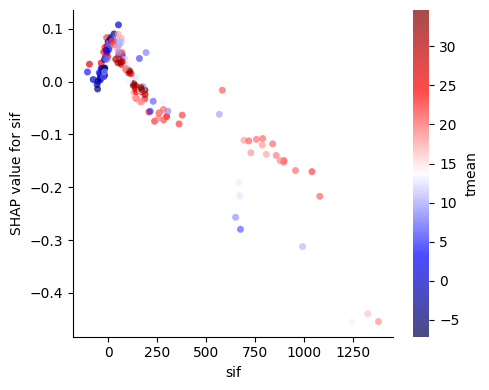

In [21]:
# test plotting shap values for a specific feature
X_train, X_test, y_train, y_test = dataset_region['southwest']['increasing']
regressor = RandomForestRegressor(random_state=42)
regressor.fit(X_train, y_train)

explainer1 = shap.TreeExplainer(regressor)
shap_values = explainer1.shap_values(X_test)

param = 'sif'
color_param = 'tmean'
param_values = X_test[param].values
param_shap_values = shap_values[:, X_test.columns.get_loc(param)]
color_param_values = X_test[color_param].values

# Plot scatter: x=sif, y=shap(sif), color=tmean
plt.figure(figsize=(5, 4))
# sc = plt.scatter(param_values, param_shap_values, c=tmean_values, cmap='coolwarm', alpha=0.7)
sc = plt.scatter(
    param_values, 
    param_shap_values, 
    c=color_param_values, 
    cmap='seismic',  
    alpha=0.7,
    s=25,
    edgecolors='none'  # removes borders around scatter dots
)

plt.xlabel(f"{param}")
plt.ylabel(f"SHAP value for {param}")


# Colorbar without border
cbar = plt.colorbar(sc, label=color_param)
cbar.outline.set_visible(False)
# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



### Sensitivity Analysis

In [32]:
X_train, X_test, y_train, y_test = dataset_region['northeast']

In [33]:
X_train

variable,ppt,tmean,tdmean,sif
41875,-0.085859,0.873830,0.995445,1.863159
33086,-0.468309,-1.369795,-1.374173,-0.942544
801,0.700386,-0.085392,0.187715,-0.086173
4383,-0.422468,-0.513848,-0.483982,-0.701959
64414,-0.314121,-0.870123,-0.976988,-0.792026
...,...,...,...,...
41374,-0.099653,-0.806060,-0.916001,-0.847542
33271,0.531070,0.981115,1.230520,1.293631
35810,-0.672121,-1.722172,-1.830711,-0.949749
3200,0.009382,0.711116,0.871003,0.278501


In [34]:
X_test["sif"].describe()

count    1908.000000
mean        0.156750
std         1.223998
min        -1.118984
25%        -0.945877
50%        -0.358840
75%         1.230553
max         3.047089
Name: sif, dtype: float64

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Define sigma shift values (perturbation levels)
sigma_levels = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]  # Adjust as needed

# Iterate through each region in the dataset
for region in list(dataset_region.keys())[:]:
    print(f"--- Region: {region} ---")

    # Extract train-test split data
    X_train, X_test, y_train, y_test = dataset_region[region]

    sigma = X_test["sif"].std()  # Standard deviation of SIF feature
    print(f"Standard Deviation of sif in test dataset: {sigma}")
    print(f'Mean of sif in test dataset: {X_test["sif"].mean()}')

    # Plot histogram of SIF values in X_test
    plt.figure(figsize=(8, 6))
    sns.histplot(X_test["sif"], bins=30, color='blue', edgecolor='black')

    plt.xlabel("SIF Values")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of SIF in Testing Dataset: {region}")
    plt.grid(True)
    # plt.show()
    hist_path = f"{folder_name}/sif_histogram_{region}.png"
    plt.savefig(hist_path, dpi=300)
    plt.close()  # Close plot to free memory

    # Initialize and train Decision Tree model
    regressor = RandomForestRegressor(random_state=42)
    regressor.fit(X_train, y_train)

    # Perform Sensitivity Analysis
    sensitivity_results = []

    for sigma_level in sigma_levels:
        # Shift SIF feature
        X_test_shifted = X_test.copy()
        X_test_shifted["sif"] += sigma * sigma_level  # Apply sigma shift

        # Predict NEE with modified SIF
        y_pred_shifted = regressor.predict(X_test_shifted)

        # Store results
        for pred in y_pred_shifted:
            sensitivity_results.append({"sigma_shift_level": sigma_level, "Prediction": pred})

    # Convert results to DataFrame
    sensitivity_df = pd.DataFrame(sensitivity_results)

    # Compute overall median of predictions
    median_values = sensitivity_df.groupby('sigma_shift_level')["Prediction"].median().reset_index()

    # Create a boxplot to visualize sensitivity
    plt.figure(figsize=(8, 6))
    # sns.boxplot(data=sensitivity_df, x="sigma_shift_level", y="Prediction", width=0.5, color='green')
    boxplot_data = [
        sensitivity_df[sensitivity_df["sigma_shift_level"] == sigma_level]["Prediction"].values
        for sigma_level in sigma_levels
    ]
    plt.boxplot(boxplot_data, positions=sigma_levels, patch_artist=True, widths=0.1)

    # Plot line connecting median values
    plt.plot(median_values["sigma_shift_level"], median_values["Prediction"], marker="o", linestyle="-", color="red", label="Median Trend")
    
    plt.xlabel("SIF Shift Level (Sigma)")
    plt.ylabel("Predicted NEE")
    plt.title(f"Sensitivity Analysis: {region}")
    plt.grid(True)

    # plt.show()  # Display the plot
    boxplot_path = f"{folder_name}/sensitivity_analys_boxplot_{region}.png"
    plt.savefig(boxplot_path, dpi=300)
    plt.close()  # Close plot to free memory



--- Region: northeast ---
Standard Deviation of sif in test dataset: 1775.2215831472251
Mean of sif in test dataset: 1848.0830871010573
--- Region: upper_midwest ---
Standard Deviation of sif in test dataset: 1559.8377903355629
Mean of sif in test dataset: 1345.4443318380488
--- Region: ohio_valley ---
Standard Deviation of sif in test dataset: 1696.8080082357687
Mean of sif in test dataset: 1742.8174786271386
--- Region: southeast ---
Standard Deviation of sif in test dataset: 1255.2495240274081
Mean of sif in test dataset: 1997.5875704166438
--- Region: northern_rockies_plains ---
Standard Deviation of sif in test dataset: 1138.9281386333644
Mean of sif in test dataset: 811.1630779043356
--- Region: south ---
Standard Deviation of sif in test dataset: 1114.730361204605
Mean of sif in test dataset: 1428.8521440926982
--- Region: southwest ---
Standard Deviation of sif in test dataset: 800.1055218893879
Mean of sif in test dataset: 469.44084630355087
--- Region: northwest ---
Standard 